# HW 9, Questions 2 and 3

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
wine = pd.read_csv("wine\wine.data")
wine

,Region,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 2a. Plot the eigenvalues of the covariance matrix in sorted order. How many principal components should be used to represent this dataset? Why?

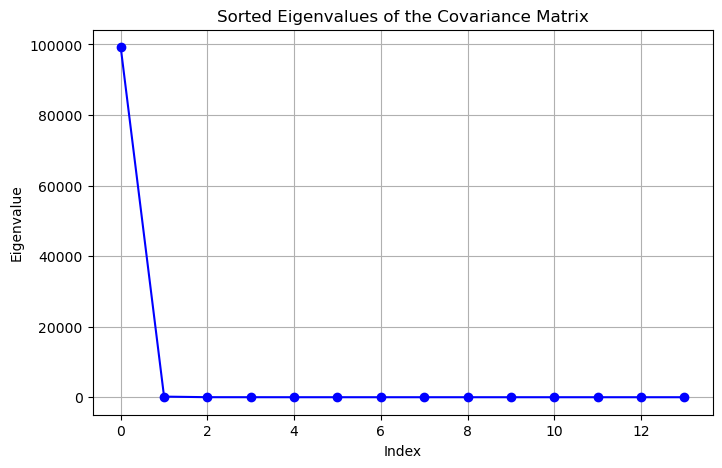

In [8]:
cov_matrix = wine.cov()
eigs = np.linalg.eigvals(cov_matrix)
eigs = np.sort(eigs)[::-1]

plt.figure(figsize=(8, 5))
plt.plot(eigs, marker='o', linestyle='-', color='b')
plt.title('Sorted Eigenvalues of the Covariance Matrix')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

Based off the plot, the number of components is 1, beacause that is where the change in eigen values occures.

## 2c. Compute the first two principal components of this dataset, and project it onto those components. Now produce a scatter plot of this two dimensional dataset, where data items of class 1 are plotted as a ‘1’, class 2 as a ‘2’, and so on.

Without Standardizing

In [14]:
X = wine.drop(['Region'], axis = 1)
y = wine['Region']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
pca = PCA(n_components=1)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.99786106])

With Standardization

In [33]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
pca = PCA(n_components=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.36198848, 0.1920749 ])

The standardized data set is better.

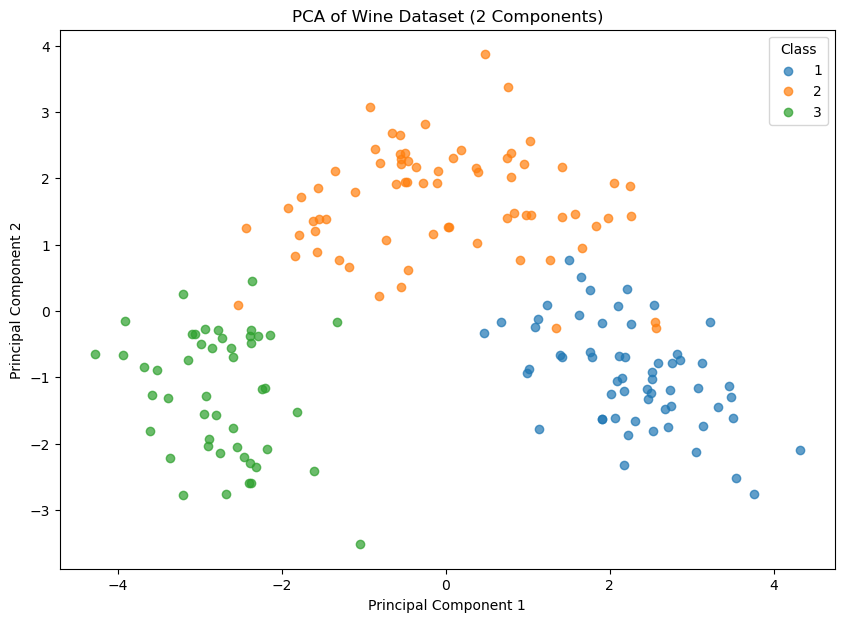

In [34]:
plt.figure(figsize=(10, 7))
for class_value in np.unique(y):
    # Select data points belonging to the current class
    subset = X_pca[y == class_value]
    # Plot each class with its label
    plt.scatter(subset[:, 0], subset[:, 1], label=str(class_value), alpha=0.7)

# Add labels and title to the plot
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset (2 Components)")
plt.legend(title="Class")
plt.show()

## 3a.Produce a scatterplot of this projection. Do you see any interesting phenomena?

In [37]:
seed = pd.read_csv(r"C:\Users\Trish\Documents\CS 361\seeds\seeds_datasetNew.txt", delimiter = '\t')
seed

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,Label
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [44]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.71874303, 0.17108184])

In [45]:
X = seed.drop(['Label'], axis = 1)
y = seed['Label']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.8293852 , 0.16363245])

There is better performance without standarization.

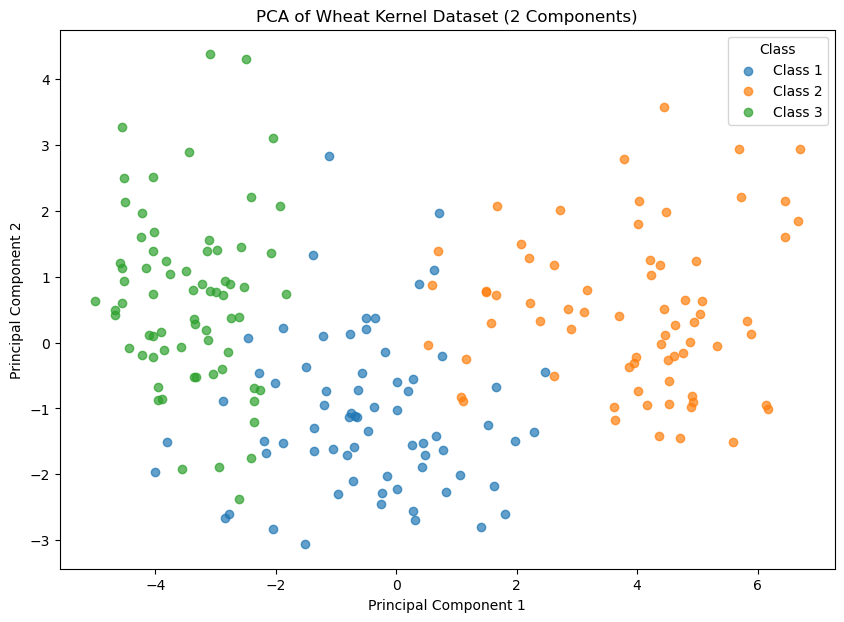

In [48]:
plt.figure(figsize=(10, 7))
for class_value in np.unique(y):
    # Select data points belonging to the current class
    subset = X_pca[y == class_value]
    # Plot each class with a unique marker and color
    plt.scatter(subset[:, 0], subset[:, 1], label=f'Class {int(class_value)}', alpha=0.7)

# Add labels and title to the plot
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wheat Kernel Dataset (2 Components)")
plt.legend(title="Class")
plt.show()

The data points forms some what of a U shaped pattern but it is not very strong. Additionally, because of how much components 1 and 3 overlap, we might need to further analyze these features.

## 3b. Plot the eigenvalues of the covariance matrix in sorted order. How many principal components should be used torepresent this dataset? why?

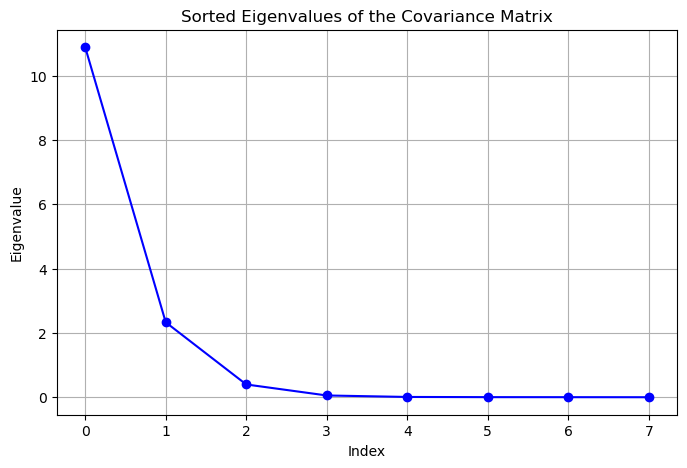

In [41]:
cov_matrix = .cov()
eigs = np.linalg.eigvals(cov_matrix)
eigs = np.sort(eigs)[::-1]

plt.figure(figsize=(8, 5))
plt.plot(eigs, marker='o', linestyle='-', color='b')
plt.title('Sorted Eigenvalues of the Covariance Matrix')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

Based off the eigenvalues,I would say 3 components because That is where the eigen values level out to 0 as the index increases. 